In [1]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

# Вероятность достижения целевого участка границы

In [2]:
def f(C, n_terms = 50):
    S = 0 
    
    for i in range(n_terms):

        B = np.pi * (2 * i + 1) / 2
        
        exponent = (- B**2) / (C + np.sqrt(C**2 + B**2))
        
        term = ( (-1)**i / (2 * i + 1) ) * np.exp(exponent)
        
        S += term
        
    return (4 / np.pi) * S

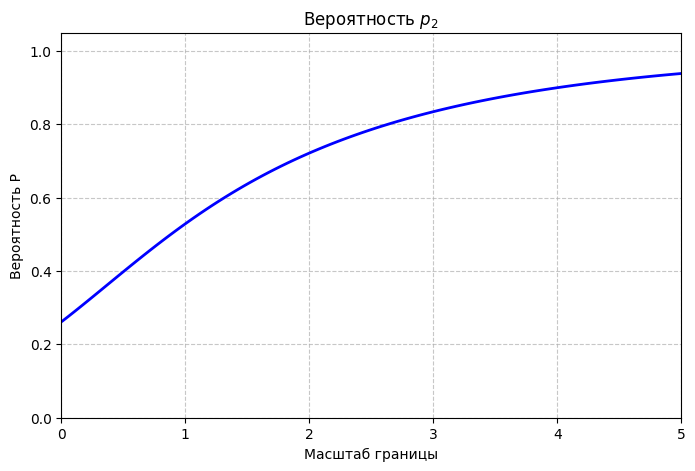

In [3]:
# график функции

x_values = np.linspace(0.01, 5, 100)  

probabilities = [f(x) for x in x_values]


plt.figure(figsize=(8, 5))
plt.plot(x_values, probabilities, color='blue', linewidth=2)

plt.title('Вероятность $p_2$')
plt.xlabel('Масштаб границы')
plt.ylabel('Вероятность P')
plt.grid(True, linestyle='--', alpha=0.7)

plt.ylim(0, 1.05)
plt.xlim(0, 5)

plt.show()

In [4]:
min_prob = f(0)
print(min_prob)

0.2609637728543127


# Поиск границы по ошибке первого рода

In [5]:
def border (alpha = 0.05, n_terms = 50):

    target_prob = 1 - alpha
    
    def objective(x):
        return f(x, n_terms) - target_prob
    
    if target_prob <= min_prob:
        raise ValueError(f"Ошибка: 1-alpha ({target_prob}) слишком мало. "
                         f"Даже при C = 0 вероятность не падает ниже ~{min_prob:.4f}")
    
    if target_prob >= 1.0:
        raise ValueError("Ошибка: вероятность строго 1 достигается только при C -> inf.")
    
    result = root_scalar(objective, bracket=[1e-4, 1000], method='brentq')
    
    if result.converged:
        return result.root
    else:
        raise RuntimeError("Алгоритм не смог сойтись к решению.")

In [6]:
# --- Пример использования ---

alpha = 0.01

C_optimal = border(alpha)

print(f"Для вероятности {1 - alpha}:")
print(f"Необходимое значение C = {C_optimal:.4f}")

# Проверка:
prob_check = f(C_optimal)
print(f"Проверка (вероятность при найденном C): {prob_check:.6f}")

Для вероятности 0.99:
Необходимое значение C = 8.8724
Проверка (вероятность при найденном C): 0.990000


# Моделирование двумерного броуновского движения, проверка для вероятности выхода за полосу

In [8]:
def walk_norm_series(n, m, T=1):
    t = np.linspace(0, T, n + 1)
    
    # Генерируем все случайные числа сразу
    Z0 = np.random.randn()
    Zk = np.random.randn(m)
    
    # 1. Считаем первый член (k=0) для всех t сразу
    W = Z0 * t / np.sqrt(T)
    
    # 2. Векторизованный расчет гармоник (k=1..m)
    # Создаем матрицу k: (m, 1)
    k_values = np.arange(1, m + 1).reshape(m, 1)
    
    # Амплитуды ak: (m, 1)
    ak = np.sqrt(2 * T) / (np.pi * k_values)
    
    # Матрица синусов: (m, n+1)
    # np.sin(pi * k * t / T)
    sin_matrix = np.sin((np.pi * k_values * t) / T)
    
    # Суммируем вклад всех гармоник (умножаем Zk на амплитуды и синусы)
    # Zk[:, None] превращает (m,) в (m, 1) для корректного умножения
    W += np.sum(Zk[:, None] * ak * sin_matrix, axis=0)
    
    return W

In [9]:
# переменные
n = 50000
m = 1000
T = 5

mu1 = -1
mu2 = -2

alpha = 0.05

In [10]:
t = np.linspace(0, T, n+1)
mu = np.sqrt(mu1**2 + mu2**2)
v = np.array([mu1, mu2])

C_optimal = border(alpha)

r0 = np.linspace(-5 + C_optimal/(mu1**2), 10 + C_optimal/(mu1**2), 100)
r1 = np.linspace(-5, 10, 100)
r2 = np.linspace(-7.5 + C_optimal/(mu1 + mu2**2), 7.5 + C_optimal/(mu1 + mu2**2), 100)
r3 = np.linspace(-5 + C_optimal/(mu1**2 + mu2**2), 10 + C_optimal/(mu1**2 + mu2**2), 100)

x0 = r0 * v[0]
y0 = r0 * v[1]
x1 = r1 * v[0]
y1 = r1 * v[1]
x2 = r2 * v[0]
y2 = r2 * v[1]
x3 = r3 * v[0]
y3 = r3 * v[1]

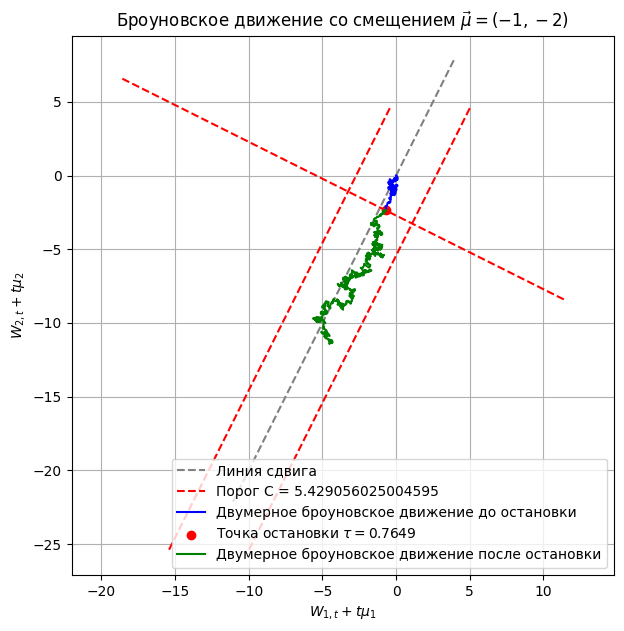

In [11]:
plt.figure(figsize=(7,7))

W1= walk_norm_series(n, m, T = T)
W2 = walk_norm_series(n, m, T = T)

Z1 = W1 + mu1 * t
Z2 = W2 + mu2 * t

condition1 = ( np.abs(Z1*mu2 - Z2*mu1) >= C_optimal)
condition2 = ( Z1*mu1 + Z2*mu2 >= C_optimal)
where_crossed = np.where(condition1 | condition2)[0]

if where_crossed.size > 0:
    idx = where_crossed[0]
    tau = t[idx]
else:
    idx = n
    tau = T

plt.plot(x3, y3, '--', label='Линия сдвига', color='gray')
plt.plot(x0, y0 - C_optimal/mu1, '--', label=f'Порог C = {C_optimal}', color='red')
plt.plot(x1, y1 + C_optimal/mu1, '--', color='red')
plt.plot(y2, -x2 + C_optimal/mu2,  '--', color='red')

plt.plot(Z1[:idx+1], Z2[:idx+1] , label = 'Двумерное броуновское движение до остановки', color = 'blue')
plt.scatter(Z1[idx], Z2[idx], label = fr'Точка остановки $\tau = {tau}$', color = 'red')
plt.plot(Z1[idx:], Z2[idx:] , label = 'Двумерное броуновское движение после остановки', color = 'green')

    
plt.title(fr'Броуновское движение со смещением $\vec{{\mu}} = ({mu1}, {mu2})$')

plt.xlabel(r'$W_{1,t} + t \mu_1 $')
plt.ylabel(r'$W_{2,t} + t \mu_2 $')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

## Численный поиск матожидания остановки

In [12]:
N = 1000
dt = T / n
t = np.linspace(dt, T, n+1)

dW = np.random.normal(0, np.sqrt(dt), size=(2, N, n+1))

W = np.cumsum(dW, axis=2)

Z1 = W[0] + mu1 * t
Z2 = W[1] + mu2 * t

condition1 = np.abs(Z1 * mu2 - Z2 * mu1) >= C_optimal
condition2 = (Z1 * mu1 + Z2 * mu2) >= C_optimal

idx1 = np.where(condition1.any(axis=1), condition1.argmax(axis=1), n)
idx2 = np.where(condition2.any(axis=1), condition2.argmax(axis=1), n)

idx_min = np.minimum(idx1, idx2)

reached = idx_min < n
if not reached.all():
    print(f"Внимание: {N - reached.sum()} траекторий не достигли границ за отведенное время T={T}.")

tau = t[idx_min[reached]]

error_type_1 = (idx1 < idx2)[reached]

print(f'Матожидание момента остановки: Etau = {tau.mean():.6f}')
print(f'Эмпирическая вероятность ошибки 1 рода: alpha = {error_type_1.mean():.6f}')

Матожидание момента остановки: Etau = 1.067981
Эмпирическая вероятность ошибки 1 рода: alpha = 0.049000


# Моделирование случайного блуждания ( приближение броуновским движением )

## Распределение шагов $X_{i} \sim Bern(\theta)$

In [20]:
N = 200

alpha = 0.05

theta_set = [1/4, 1/2, 3/4]
theta0 = 1/2
theta1 = 1/4
theta2 = 3/4

In [21]:
C_optimal = border(alpha)

a1 = np.log(theta1 / theta0)
a2 = np.log(theta2 / theta0)

b1 = np.log((1 - theta1) / (1 - theta0))
b2 = np.log((1 - theta2) / (1 - theta0))

k1 = a1 - b1
k2 = a2 - b2

a_01 = theta0 * k1 + b1 # среднее логарифма отношения правдоподобий при гипотезе
a_02 = theta0 * k2 + b2 # -//-

sigma_01 = ( k1 ** 2 ) * theta0 * (1 - theta0) # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе
sigma_02 = ( k2 ** 2 ) * theta0 * (1 - theta0) # -//-

mu1 = a_01 / sigma_01
mu2 = a_02 / sigma_02

mu = np.sqrt(mu1**2 + mu2**2)

In [22]:
v = np.array([mu1, mu2])
n_dir = np.array([-mu2, mu1]) / mu
p_top = C_optimal / mu * n_dir
p_bottom = -C_optimal / mu * n_dir

u_dir = v / mu
p_stop = C_optimal / mu * u_dir

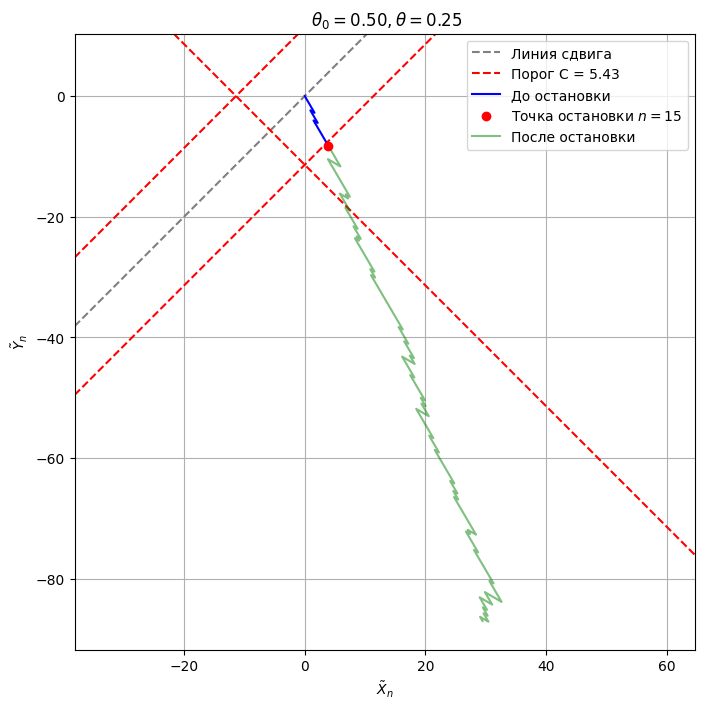

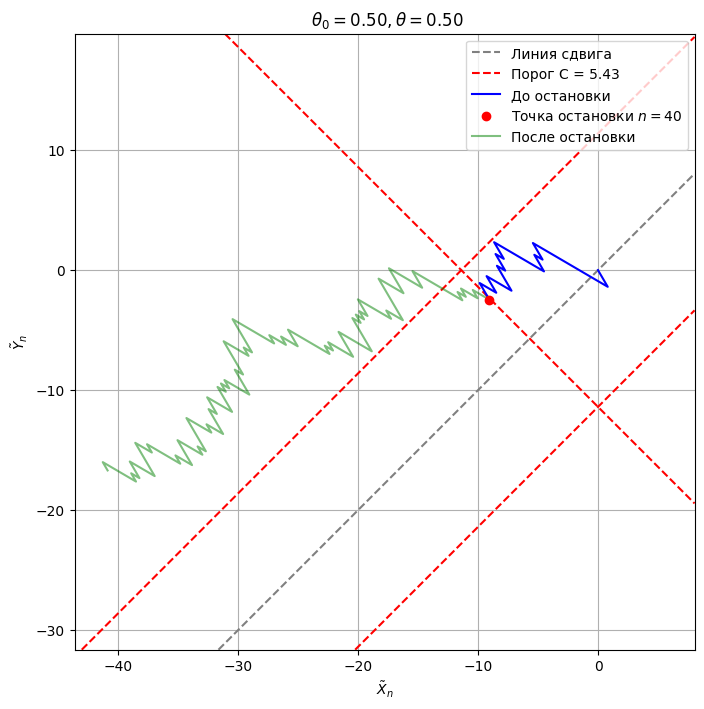

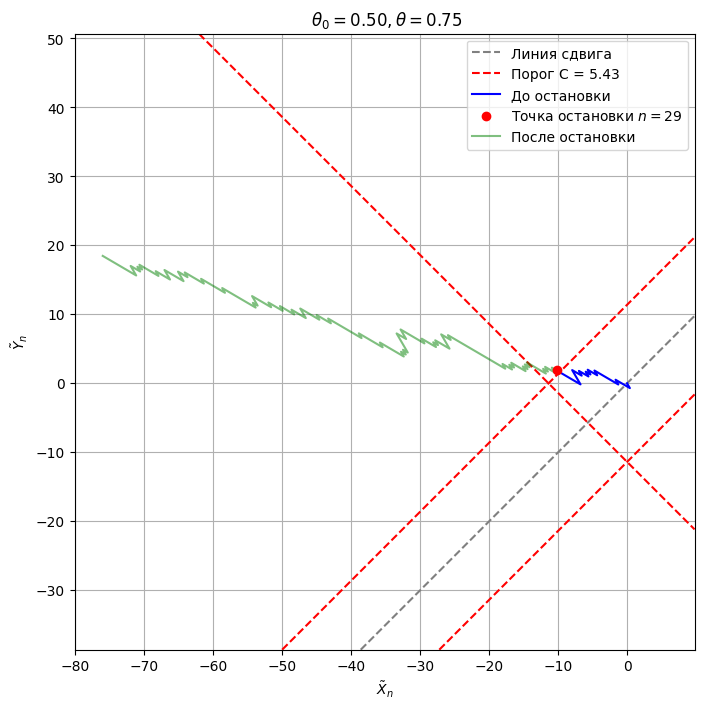

In [23]:
for theta in theta_set:    
    
    x = sps.bernoulli.rvs(p=theta, size=N)
    
    step_X = x * k1 + b1
    step_Y = x * k2 + b2
    
    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)

    X[1:] = np.cumsum(step_X)
    Y[1:] = np.cumsum(step_Y)
    
    condition1 = (np.abs(X * mu2 - Y * mu1) >= C_optimal)
    condition2 = (X * mu1 + Y * mu2 >= C_optimal)
    where_crossed = np.where(condition1 | condition2)[0]

    if where_crossed.size > 0:
        idx = where_crossed[0]
    else:
        idx = N

    # Отрисовка    
    plt.figure(figsize=(8, 8))

    plt.axline((0, 0), v, color='gray', linestyle='--', label='Линия сдвига')

    plt.axline(p_top, p_top + v, color='red', linestyle='--', label=f'Порог C = {C_optimal:.2f}')
    plt.axline(p_bottom, p_bottom + v, color='red', linestyle='--')
    plt.axline(p_stop, p_stop + n_dir, color='red', linestyle='--')

    plt.plot(X[:idx+1], Y[:idx+1], color='blue', label='До остановки')
    
    if idx < N:
        plt.scatter(X[idx], Y[idx], label=fr'Точка остановки $n = {idx}$', color='red', zorder=5)
        plt.plot(X[idx:], Y[idx:], color='green', alpha=0.5, label='После остановки')
        
    plt.title(fr' $\theta_0 = {theta0:.2f}, \theta = {theta:.2f} $')
    plt.xlabel(r'$\tilde{X}_{n}$') 
    plt.ylabel(r'$\tilde{Y}_{n}$')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

## Распределения шагов: $X_{i} \sim N(\theta, \sigma^2), \sigma = \textbf{const}$

In [32]:
N = 50

alpha = 0.05

theta_set = [-1, 0, 1]
theta0 = 0
theta1 = -1
theta2 = 1

sigma = 1

In [33]:
C_optimal = border(alpha)

a_01 = ( (theta1 - theta0) ** 2 ) / ( 2 * (sigma ** 2) )  # среднее логарифма отношения правдоподобий при гипотезе
a_02 = ( (theta2 - theta0) ** 2 ) / ( 2 * (sigma ** 2) ) # -//-

sigma_01 = 2 * a_01  # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе
sigma_02 = 2 * a_02 # -//-

mu1 = - a_01 / sigma_01
mu2 = - a_02 / sigma_02

mu = np.sqrt(mu1**2 + mu2**2)

In [34]:
v = np.array([mu1, mu2])
n_dir = np.array([-mu2, mu1]) / mu
p_top = C_optimal / mu * n_dir
p_bottom = -C_optimal / mu * n_dir

u_dir = v / mu
p_stop = C_optimal / mu * u_dir


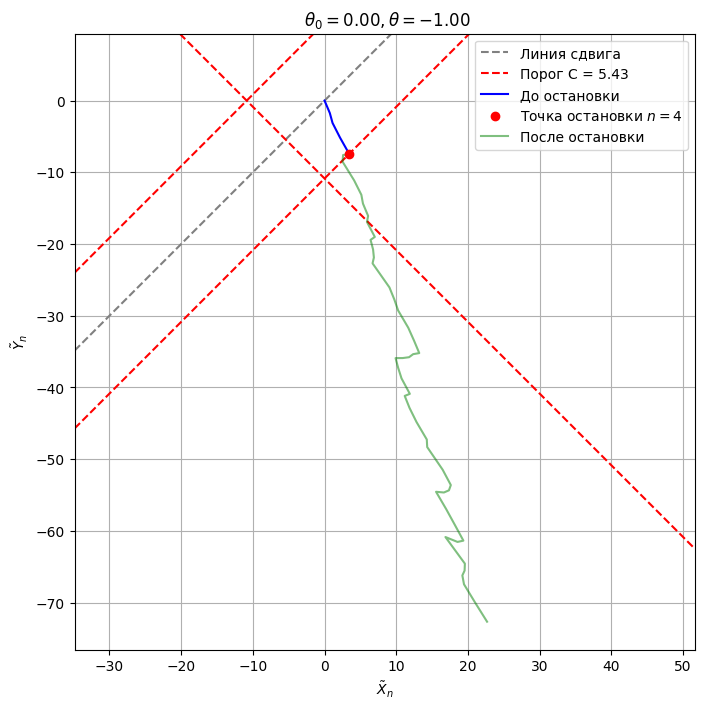

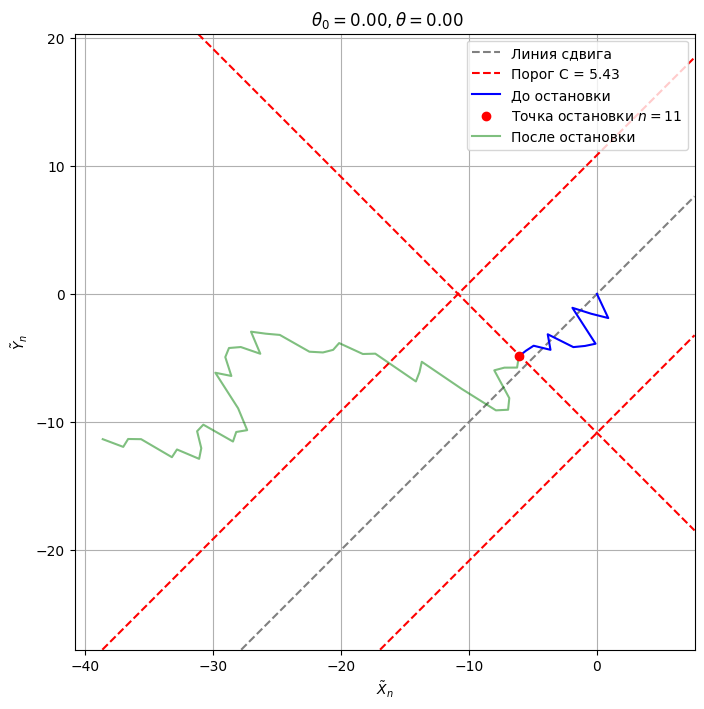

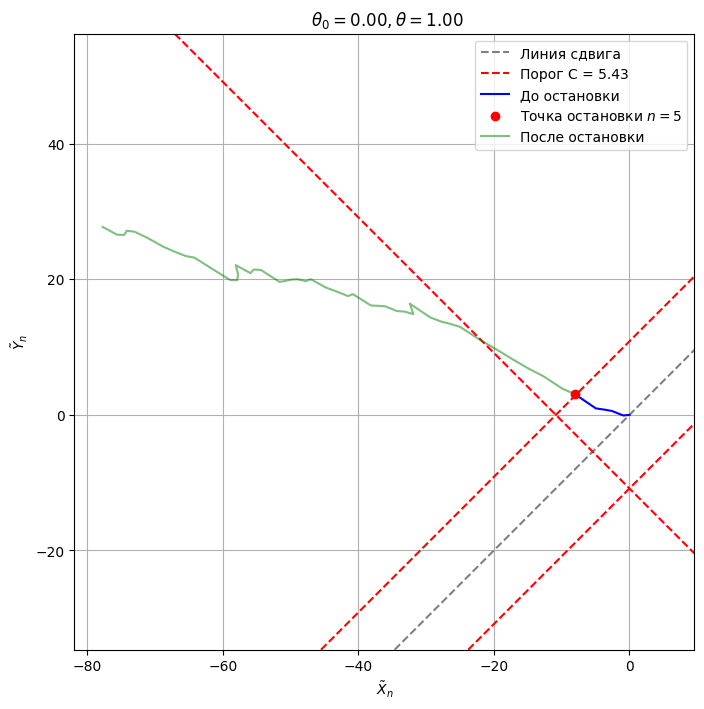

In [35]:
for theta in theta_set:    
    
    x = sps.norm.rvs(loc=theta, scale=sigma, size=N)
    
    step_X = (theta1 - theta0) * (x - theta0) / (sigma**2) - a_01
    step_Y = (theta2 - theta0) * (x - theta0) / (sigma**2) - a_02
    
    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)

    X[1:] = np.cumsum(step_X)
    Y[1:] = np.cumsum(step_Y)
    
    condition1 = (np.abs(X * mu2 - Y * mu1) >= C_optimal)
    condition2 = (X * mu1 + Y * mu2 >= C_optimal)
    where_crossed = np.where(condition1 | condition2)[0]

    if where_crossed.size > 0:
        idx = where_crossed[0]
    else:
        idx = N

    # Отрисовка    
    plt.figure(figsize=(8, 8))

    plt.axline((0, 0), v, color='gray', linestyle='--', label='Линия сдвига')

    plt.axline(p_top, p_top + v, color='red', linestyle='--', label=f'Порог C = {C_optimal:.2f}')
    plt.axline(p_bottom, p_bottom + v, color='red', linestyle='--')
    plt.axline(p_stop, p_stop + n_dir, color='red', linestyle='--')

    plt.plot(X[:idx+1], Y[:idx+1], color='blue', label='До остановки')
    
    if idx < N:
        plt.scatter(X[idx], Y[idx], label=fr'Точка остановки $n = {idx}$', color='red', zorder=5)
        plt.plot(X[idx:], Y[idx:], color='green', alpha=0.5, label='После остановки')
        
    plt.title(fr' $\theta_0 = {theta0:.2f}, \theta = {theta:.2f} $')
    plt.xlabel(r'$\tilde{X}_{n}$') 
    plt.ylabel(r'$\tilde{Y}_{n}$')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

## Распределение шагов $X_i \sim Weibull(\theta, \lambda), \lambda = \textbf{const}$

In [7]:
from scipy.special import gamma, digamma

In [8]:
gamma_e = np.euler_gamma

def get_orthonormal_basis(sigma_11, sigma_22, sigma_12):
    
    # Проверка на вырожденный случай (если матрица уже диагональна)
    if np.isclose(sigma_12, 0):
        P = np.array([[1.0, 0.0], 
                      [0.0, 1.0]])
        lambdas = np.array([sigma_11, sigma_22])
        return P, lambdas

    # 1. Вычисление собственных значений
    trace = sigma_11 + sigma_22
    diff = sigma_11 - sigma_22
    discriminant = np.sqrt(diff**2 + 4 * sigma_12**2)
    
    lambda_1 = (trace + discriminant) / 2
    lambda_2 = (trace - discriminant) / 2
    
    # 2. Вычисление ненормированных собственных векторов
    v1 = np.array([sigma_12, lambda_1 - sigma_11])
    v2 = np.array([sigma_12, lambda_2 - sigma_11])
    
    # 3. Нормировка векторов
    e1 = v1 / np.linalg.norm(v1)
    e2 = v2 / np.linalg.norm(v2)
    
    # Матрица перехода P (ортонормированный базис записан по столбцам)
    P = np.column_stack((e1, e2))
    lambdas = np.array([lambda_1, lambda_2])
    
    return P, lambdas


def cov_weibull_ll(a_i, a_j):
    A = gamma(a_i + a_j + 1) - gamma(a_i + 1) * gamma(a_j + 1) - a_i * gamma(a_i + 1) - a_j * gamma(a_j + 1) + a_i + a_j - 1
    
    term_i = gamma(a_i + 1) * digamma(a_i + 1) + gamma_e * gamma(a_i + 1)
    term_j = gamma(a_j + 1) * digamma(a_j + 1) + gamma_e * gamma(a_j + 1)
    
    B = -(a_j - 1) * term_i - (a_i - 1) * term_j
    
    C = (a_i - 1) * (a_j - 1) * (np.pi**2) / 6
    
    return A + B + C


In [20]:
N = 15

alpha = 0.000001

theta_set = [2/4, 1, 2]
theta0 = 1
theta1 = 2/3
theta2 = 3/2

alpha1 = theta1 / theta0
alpha2 = theta2 / theta0

In [21]:
ln_1 = np.log(alpha1)
ln_2 = np.log(alpha2)


a_01 = 1 - gamma(alpha1 + 1) - (alpha1 - 1) * gamma_e + ln_1 # среднее логарифма отношения правдоподобий при гипотезе
a_02 = 1 - gamma(alpha2 + 1) - (alpha2 - 1) * gamma_e + ln_2 # -//-

sigma_0_11 = cov_weibull_ll(alpha1, alpha1)
sigma_0_22 = cov_weibull_ll(alpha2, alpha2)

sigma_0_12 = cov_weibull_ll(alpha1, alpha2)

P, lambdas = get_orthonormal_basis(sigma_0_11, sigma_0_22, sigma_0_12)

In [22]:
# Исходный вектор матожиданий
a_old = np.array([a_01, a_02])

# Переводим вектор матожиданий в новый базис
a = P.T @ a_old

# Находим вектор сдвига
mu1_new, mu2_new = a[0] / lambdas[0] , a[1] / lambdas[1]

v = np.array([mu1_new, mu2_new])

mu = np.sqrt(mu1_new ** 2 + mu2_new ** 2)


In [23]:
n_dir = np.array([-mu2_new, mu1_new]) / mu
p_top = C_optimal / mu * n_dir
p_bottom = -C_optimal / mu * n_dir

u_dir = v / mu
p_stop = C_optimal / mu * u_dir

In [ ]:
"""
    step_X = y ** (theta0 / theta) - y ** (theta1 / theta) + ((theta1 - theta0) / theta) * np.log(y) + ln_1
    step_Y = y ** (theta0 / theta) - y ** (theta2 / theta) + ((theta2 - theta0) / theta) * np.log(y) + ln_2

    X_old = np.zeros(N + 1)
    Y_old = np.zeros(N + 1)

    X_old[1:] = np.cumsum(step_X)
    Y_old[1:] = np.cumsum(step_Y)

    # Поворот траектории (переход в новый диагональный базис)
    XY_old = np.vstack((X_old, Y_old))
    XY_new = P.T @ XY_old

    X = XY_new[0]
    Y = XY_new[1]
"""

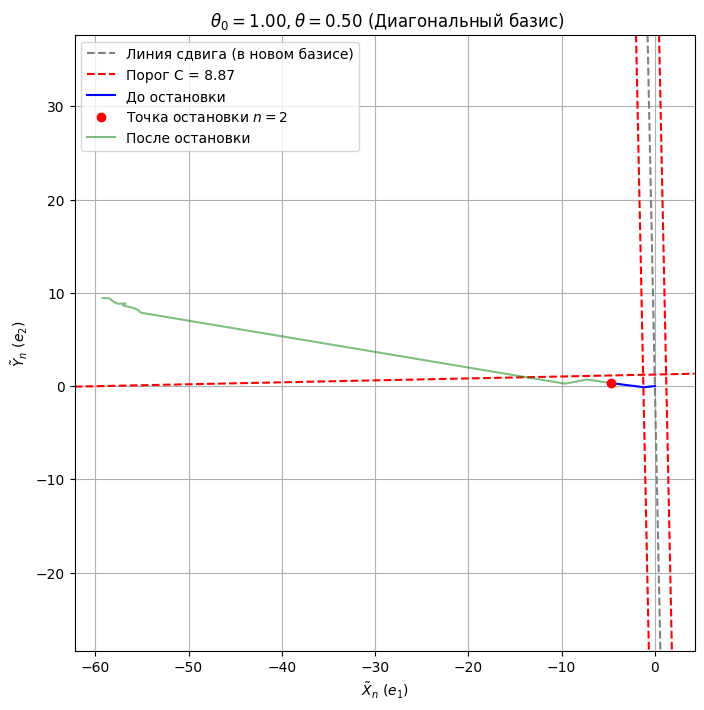

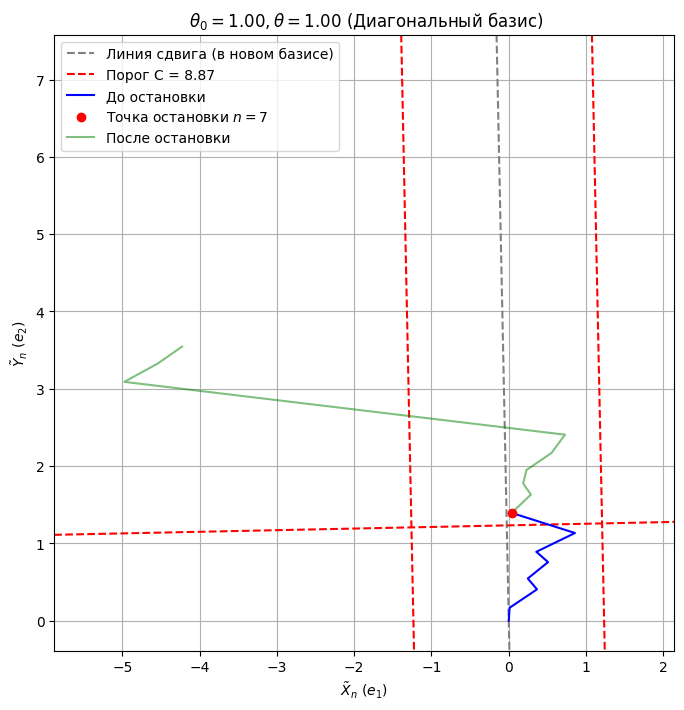

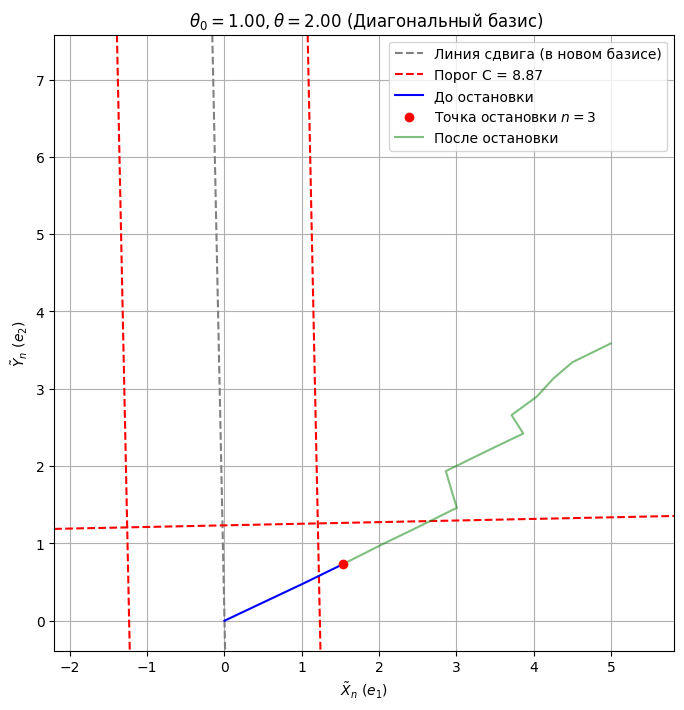

In [25]:
for theta in theta_set:
    
    y = sps.expon.rvs(scale=1, size=N)

    step_X_old = y ** (theta0 / theta) - y ** (theta1 / theta) + ((theta1 - theta0) / theta) * np.log(y) + ln_1
    step_Y_old = y ** (theta0 / theta) - y ** (theta2 / theta) + ((theta2 - theta0) / theta) * np.log(y) + ln_2

    step_XY_old = np.vstack((step_X_old, step_Y_old))
    step_XY_new = P.T @ step_XY_old

    step_X_new = step_XY_new[0]
    step_Y_new = step_XY_new[1]

    X = np.zeros(N + 1)
    Y = np.zeros(N + 1)

    X[1:] = np.cumsum(step_X_new)
    Y[1:] = np.cumsum(step_Y_new)
    
    condition1 = (np.abs(X * mu2_new - Y * mu1_new) >= C_optimal)
    condition2 = (X * mu1_new + Y * mu2_new >= C_optimal)
    where_crossed = np.where(condition1 | condition2)[0]

    if where_crossed.size > 0:
        idx = where_crossed[0]
    else:
        idx = N

    # Отрисовка    
    plt.figure(figsize=(8, 8))

    plt.axline((0, 0), v, color='gray', linestyle='--', label='Линия сдвига (в новом базисе)')

    plt.axline(p_top, p_top + v, color='red', linestyle='--', label=f'Порог C = {C_optimal:.2f}')
    plt.axline(p_bottom, p_bottom + v, color='red', linestyle='--')
    plt.axline(p_stop, p_stop + n_dir, color='red', linestyle='--')

    plt.plot(X[:idx+1], Y[:idx+1], color='blue', label='До остановки')
    
    if idx < N:
        plt.scatter(X[idx], Y[idx], label=fr'Точка остановки $n = {idx}$', color='red', zorder=5)
        plt.plot(X[idx:], Y[idx:], color='green', alpha=0.5, label='После остановки')
        
    plt.title(fr' $\theta_0 = {theta0:.2f}, \theta = {theta:.2f} $ (Диагональный базис)')
    plt.xlabel(r'$\tilde{X}_{n} \ (e_1)$') 
    plt.ylabel(r'$\tilde{Y}_{n} \ (e_2)$')
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()

## Эмпирическая вероятность 1 рода
$X_{i} \sim N(\theta, \sigma^2), \sigma = \textbf{const}$

In [48]:
M = 30000
N = 200

N_nodes = np.arange(N+1)

alpha = 0.01

theta0 = 0
theta1 = -1
theta2 = 1

sigma = 1

C_optimal = border(alpha)

a_01 = ( (theta1 - theta0) ** 2 ) / ( 2 * (sigma ** 2) )  # среднее логарифма отношения правдоподобий при гипотезе
a_02 = ( (theta2 - theta0) ** 2 ) / ( 2 * (sigma ** 2) ) # -//-

sigma_01 = 2 * a_01  # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе
sigma_02 = 2 * a_02 # -//-

mu1 = - a_01 / sigma_01
mu2 = - a_02 / sigma_02

mu = np.sqrt(mu1**2 + mu2**2)


In [ ]:
theta = theta0

print(f"Запуск симуляции Монте-Карло ({M} итераций) для theta0 = {theta0:.2f}, theta = {theta:.2f}...")

x_mc = sps.norm.rvs(loc=theta, scale=sigma, size=(M, N))

step_X_mc = (theta1 - theta0) * (x_mc - theta0) / (sigma**2) - a_01
step_Y_mc = (theta2 - theta0) * (x_mc - theta0) / (sigma**2) - a_02

X_mc = np.zeros((M, N + 1))
Y_mc = np.zeros((M, N + 1))

X_mc[:, 1:] = np.cumsum(step_X_mc, axis=1)
Y_mc[:, 1:] = np.cumsum(step_Y_mc, axis=1)

condition1_mc = np.abs(X_mc * mu2 - Y_mc * mu1) >= C_optimal
condition2_mc = X_mc * mu1 + Y_mc * mu2 >= C_optimal

idx1 = np.where(condition1_mc.any(axis=1), condition1_mc.argmax(axis=1), N)
idx2 = np.where(condition2_mc.any(axis=1), condition2_mc.argmax(axis=1), N)

idx_min = np.minimum(idx1, idx2)

reached = idx_min < N

if not reached.all():
    print(f"Внимание: {M - reached.sum()} траекторий не достигли границ за отведенное количество шагов N={N}.")

tau = N_nodes[idx_min[reached]]

error_type_1 = (idx1 < idx2)[reached]

print(f'Заданная вероятность ошибки 1 рода: alpha = {alpha}')
print(f'Матожидание момента остановки: Etau = {tau.mean():.6f}')
print(f'Эмпирическая вероятность ошибки 1 рода: alpha = {error_type_1.mean():.6f}')

Запуск симуляции Монте-Карло (30000 итераций) для theta0 = 0.00, theta = 0.00...
Заданная вероятность ошибки 1 рода: alpha = 0.01
Матожидание момента остановки: Etau = 17.809933
Эмпирическая вероятность ошибки 1 рода: alpha = 0.044333


## Эмпирическая мощность
$X_{i} \sim N(\theta, \sigma^2), \sigma = \textbf{const}$

In [ ]:
M = 30000
N = 200

N_nodes = np.arange(N+1)

alpha = 0.01

theta0 = 0
theta1 = -1
theta2 = 1

sigma = 1

C_optimal = border(alpha)

a_01 = ( (theta1 - theta0) ** 2 ) / ( 2 * (sigma ** 2) )  # среднее логарифма отношения правдоподобий при гипотезе
a_02 = ( (theta2 - theta0) ** 2 ) / ( 2 * (sigma ** 2) ) # -//-

sigma_01 = 2 * a_01  # дисперсия (sigma^2 !!!) логарифма отношения правдоподобий при гипотезе
sigma_02 = 2 * a_02 # -//-

mu1 = - a_01 / sigma_01
mu2 = - a_02 / sigma_02

mu = np.sqrt(mu1**2 + mu2**2)

In [53]:
theta = theta2

print(f"Запуск симуляции Монте-Карло ({M} итераций) для theta0 = {theta0:.2f}, theta = {theta:.2f}...")

x_mc = sps.norm.rvs(loc=theta, scale=sigma, size=(M, N))

step_X_mc = (theta1 - theta0) * (x_mc - theta0) / (sigma**2) - a_01
step_Y_mc = (theta2 - theta0) * (x_mc - theta0) / (sigma**2) - a_02

X_mc = np.zeros((M, N + 1))
Y_mc = np.zeros((M, N + 1))

X_mc[:, 1:] = np.cumsum(step_X_mc, axis=1)
Y_mc[:, 1:] = np.cumsum(step_Y_mc, axis=1)

condition1_mc = np.abs(X_mc * mu2 - Y_mc * mu1) >= C_optimal
condition2_mc = X_mc * mu1 + Y_mc * mu2 >= C_optimal

idx1 = np.where(condition1_mc.any(axis=1), condition1_mc.argmax(axis=1), N)
idx2 = np.where(condition2_mc.any(axis=1), condition2_mc.argmax(axis=1), N)

idx_min = np.minimum(idx1, idx2)

reached = idx_min < N

if not reached.all():
    print(f"Внимание: {M - reached.sum()} траекторий не достигли границ за отведенное количество шагов N={N}.")

tau = N_nodes[idx_min[reached]]

power = (idx1 < idx2)[reached]

print(f'Матожидание момента остановки: Etau = {tau.mean():.6f}')
print(f'Эмпирическая мощность: 1 - beta = {power.mean():.6f}')

Запуск симуляции Монте-Карло (30000 итераций) для theta0 = 0.00, theta = 1.00...
Матожидание момента остановки: Etau = 9.723900
Эмпирическая мощность: 1 - beta = 0.980633
